In [1]:
import os, sys, importlib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6, 6)

def normalize_img(arr: np.ndarray) -> np.ndarray:
    """Scale to [0,1] regardless of dtype."""
    if arr.dtype == np.uint8:
        return arr.astype(np.float32) / 255.0
    if arr.dtype == np.uint16:
        return arr.astype(np.float32) / 65535.0
    arr = arr.astype(np.float32)
    mn, mx = float(arr.min()), float(arr.max())
    return (arr - mn) / (mx - mn + 1e-8)

def load_image_any(path: str, target_size: int = 512, bands=(1,2,3)) -> torch.Tensor:
    """
    Loads PNG/JPG/TIF to a tensor (1,3,H,W) resized to (1,3,target_size,target_size).
    For TIF, selects the given bands (1-indexed).
    """
    ext = os.path.splitext(path)[1].lower()
    if ext in [".tif", ".tiff"]:
        import rasterio
        with rasterio.open(path) as src:
            # pick bands safely (fall back if image has fewer)
            max_b = min(len(bands), src.count)
            use_bands = [b for b in bands[:max_b] if b <= src.count]
            data = src.read(use_bands)                    # (C,H,W)
            if data.shape[0] < 3:                         # pad to 3 channels if needed
                last = data[-1:, ...]
                data = np.concatenate([data, last.repeat(3 - data.shape[0], axis=0)], axis=0)
            data = normalize_img(data)                    # (3,H,W) -> [0,1]
            img = torch.from_numpy(data).float()          # (3,H,W)
    else:
        img_pil = Image.open(path).convert("RGB")
        arr = normalize_img(np.array(img_pil))            # (H,W,3)
        img = torch.from_numpy(arr).permute(2,0,1).float()# (3,H,W)

    img = img.unsqueeze(0)                                # (1,3,H,W)
    img = F.interpolate(img, size=(target_size, target_size), mode="bilinear", align_corners=False)
    return img

def load_mask_png(path: str, target_size: int = 512) -> torch.Tensor:
    """Loads a grayscale PNG mask to (1,1,H,W) in [0,1]."""
    m = Image.open(path).convert("L")
    m = normalize_img(np.array(m))                        # (H,W)
    m = torch.from_numpy(m).float().unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
    m = F.interpolate(m, size=(target_size, target_size), mode="nearest")
    return m

def show_image_and_mask(img: torch.Tensor, mask: torch.Tensor, alpha=0.4):
    """
    img:  (1,3,H,W) in [0,1]
    mask: (1,1,H,W) in [0,1]
    """
    img_np = img[0].permute(1,2,0).cpu().numpy()
    mask_np = mask[0,0].cpu().numpy()
    fig, ax = plt.subplots()
    ax.imshow(img_np)
    ax.imshow(mask_np, alpha=alpha)
    ax.set_axis_off()
    plt.show()


Image tensor: dtype=torch.float32, shape=(1, 3, 512, 512), min=0.000, max=1.000
Mask  tensor: dtype=torch.float32, shape=(1, 1, 512, 512), min=0.000, max=1.000


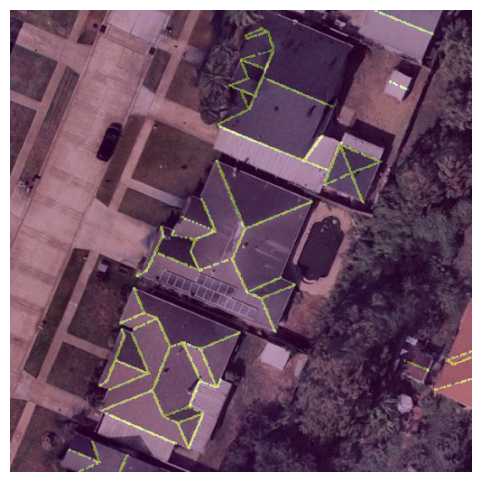

In [4]:
# ====== EDIT THESE ======
IMAGE_PATH = r"data\train\image\29.955597_-90.003119_nearmap_rgb.tif"   # <-- EDIT (supports .tif/.png/.jpg)
MASK_PATH  = r"data\train\image\29.955597_-90.003119_nearmap_rgb_mask.png"  # <-- EDIT (PNG mask)
TARGET_SIZE = 512
# ========================

x = load_image_any(IMAGE_PATH, target_size=TARGET_SIZE)  # (1,3,512,512)
m = load_mask_png(MASK_PATH, target_size=TARGET_SIZE)    # (1,1,512,512)

print(f"Image tensor: dtype={x.dtype}, shape={tuple(x.shape)}, min={x.min():.3f}, max={x.max():.3f}")
print(f"Mask  tensor: dtype={m.dtype}, shape={tuple(m.shape)}, min={m.min():.3f}, max={m.max():.3f}")

assert x.shape[1] == 3, f"Expected 3 input channels, got {x.shape[1]} — likely TIF band selection issue."
show_image_and_mask(x, m)


In [5]:
# If your project root has models/unet.py with class UNet
PROJECT_ROOT = r"E:\\Inner Edge\\Labelled\\misc\\RidgeData"  # <-- EDIT
sys.path.append(PROJECT_ROOT)

MODEL_IMPORT = "models.unet"   # module path  <-- EDIT if needed
CLASS_NAME   = "UNet"          # class name   <-- EDIT if needed
MODEL_KWARGS = dict(in_channels=3, out_channels=1)  # <-- EDIT to match your unet.py

mod = importlib.import_module(MODEL_IMPORT)
UNet = getattr(mod, CLASS_NAME)
model = UNet(**MODEL_KWARGS).eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
x = x.to(device)

print(model.__class__.__name__, "loaded on", device)


UNet loaded on cpu


In [6]:
def register_shape_hooks(model: nn.Module, verbose_classes=None):
    """
    Registers forward hooks that print tensor shapes for selected module classes.
    If verbose_classes=None -> prints ALL named modules.
    """
    handles = []
    def make_hook(name):
        def _hook(module, inp, out):
            def _shape(z):
                try: return tuple(z.shape)
                except: return type(z).__name__
            in_shape = _shape(inp[0]) if isinstance(inp, (list, tuple)) and len(inp) else _shape(inp)
            out_shape = _shape(out)
            print(f"{name:<40} {module.__class__.__name__:<22} in {in_shape} -> out {out_shape}")
        return _hook

    for name, m in model.named_modules():
        if name == "":   # skip root
            continue
        if (verbose_classes is None) or isinstance(m, verbose_classes):
            handles.append(m.register_forward_hook(make_hook(name)))
    return handles

# Print common layers; set verbose_classes=None to print EVERYTHING
verbose_classes = (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d,
                   nn.ReLU, nn.SiLU, nn.LeakyReLU, nn.MaxPool2d,
                   nn.Upsample, nn.Identity)

handles = register_shape_hooks(model, verbose_classes=verbose_classes)

with torch.no_grad():
    y = model(x)

for h in handles: h.remove()
print(f"[MODEL OUTPUT] shape={tuple(y.shape)}, dtype={y.dtype}")


enc1.double_conv.0                       Conv2d                 in (1, 3, 512, 512) -> out (1, 64, 512, 512)
enc1.double_conv.1                       ReLU                   in (1, 64, 512, 512) -> out (1, 64, 512, 512)
enc1.double_conv.2                       Conv2d                 in (1, 64, 512, 512) -> out (1, 64, 512, 512)
enc1.double_conv.3                       ReLU                   in (1, 64, 512, 512) -> out (1, 64, 512, 512)
pool                                     MaxPool2d              in (1, 64, 512, 512) -> out (1, 64, 256, 256)
enc2.double_conv.0                       Conv2d                 in (1, 64, 256, 256) -> out (1, 128, 256, 256)
enc2.double_conv.1                       ReLU                   in (1, 128, 256, 256) -> out (1, 128, 256, 256)
enc2.double_conv.2                       Conv2d                 in (1, 128, 256, 256) -> out (1, 128, 256, 256)
enc2.double_conv.3                       ReLU                   in (1, 128, 256, 256) -> out (1, 128, 256, 256)
pool

In [8]:
for name, m in model.named_modules():
    if name != "":
        print(name, "->", m.__class__.__name__)


enc1 -> DoubleConv
enc1.double_conv -> Sequential
enc1.double_conv.0 -> Conv2d
enc1.double_conv.1 -> ReLU
enc1.double_conv.2 -> Conv2d
enc1.double_conv.3 -> ReLU
enc2 -> DoubleConv
enc2.double_conv -> Sequential
enc2.double_conv.0 -> Conv2d
enc2.double_conv.1 -> ReLU
enc2.double_conv.2 -> Conv2d
enc2.double_conv.3 -> ReLU
enc3 -> DoubleConv
enc3.double_conv -> Sequential
enc3.double_conv.0 -> Conv2d
enc3.double_conv.1 -> ReLU
enc3.double_conv.2 -> Conv2d
enc3.double_conv.3 -> ReLU
enc4 -> DoubleConv
enc4.double_conv -> Sequential
enc4.double_conv.0 -> Conv2d
enc4.double_conv.1 -> ReLU
enc4.double_conv.2 -> Conv2d
enc4.double_conv.3 -> ReLU
pool -> MaxPool2d
bottleneck -> DoubleConv
bottleneck.double_conv -> Sequential
bottleneck.double_conv.0 -> Conv2d
bottleneck.double_conv.1 -> ReLU
bottleneck.double_conv.2 -> Conv2d
bottleneck.double_conv.3 -> ReLU
upconv4 -> ConvTranspose2d
dec4 -> DoubleConv
dec4.double_conv -> Sequential
dec4.double_conv.0 -> Conv2d
dec4.double_conv.1 -> ReLU
dec

In [7]:
def sanity(x):
    assert x.dtype in (torch.float32, torch.float16), f"Input dtype must be float*, got {x.dtype}"
    assert x.ndim == 4, f"Expected [B,C,H,W], got {x.shape}"
    assert x.shape[1] == 3, f"Expected 3 channels (RGB), got {x.shape[1]}"
    print("✅ sanity OK:", tuple(x.shape), x.dtype)

sanity(x)


✅ sanity OK: (1, 3, 512, 512) torch.float32


In [ ]:
model = UNet(in_channels=3, out_channels=1)  # your class
#x = image

# Encoder 1
x1 = model.enc1(x)
print("enc1:", x1.shape)

# Pool + Encoder 2
x2 = model.pool(x1)
x2 = model.enc2(x2)
print("enc2:", x2.shape)

# Pool + Encoder 3
x3 = model.pool(x2)
x3 = model.enc3(x3)
print("enc3:", x3.shape)

# Pool + Encoder 3
x4 = model.pool(x3)
x4 = model.enc4(x4)
print("enc3:", x4.shape)

#----encoders end ------#


enc1: torch.Size([1, 64, 512, 512])
enc2: torch.Size([1, 128, 256, 256])
enc3: torch.Size([1, 256, 128, 128])
enc3: torch.Size([1, 512, 64, 64])


In [13]:
xb = model.bottleneck(model.pool(x4))
print("bottleneck:", xb.shape)

bottleneck: torch.Size([1, 1024, 32, 32])


In [15]:
#---decoder blocks---#
# Decoder 1: bottleneck -> dec4
u4 = model.upconv4(xb)             # Upsample: (B, 1024, 32, 32) → (B, 512, 64, 64)
print("upconv4:", u4.shape)

u4 = torch.cat((u4, x4), dim=1)    # Skip connection: concat with enc4 output
print("concat with x4:", u4.shape) # Expect (B, 1024, 64, 64)

u4 = model.dec4(u4)                # Double conv block
print("dec4:", u4.shape)           # Expect (B, 512, 64, 64)

# Decoder 2: dec4 -> dec3
u3 = model.upconv3(u4)             # (B, 512, 64, 64) → (B, 256, 128, 128)
print("upconv3:", u3.shape)

u3 = torch.cat((u3, x3), dim=1)    # Concat with enc3 output
print("concat with x3:", u3.shape) # Expect (B, 512, 128, 128)

u3 = model.dec3(u3)
print("dec3:", u3.shape)           # Expect (B, 256, 128, 128)

# Decoder 3: dec3 -> dec2
u2 = model.upconv2(u3)             # (B, 256, 128, 128) → (B, 128, 256, 256)
print("upconv2:", u2.shape)

u2 = torch.cat((u2, x2), dim=1)    # Concat with enc2 output
print("concat with x2:", u2.shape) # Expect (B, 256, 256, 256)

u2 = model.dec2(u2)
print("dec2:", u2.shape)           # Expect (B, 128, 256, 256)
# Decoder 4: dec2 -> dec1
u1 = model.upconv1(u2)             # (B, 128, 256, 256) → (B, 64, 512, 512)
print("upconv1:", u1.shape)

u1 = torch.cat((u1, x1), dim=1)    # Concat with enc1 output
print("concat with x1:", u1.shape) # Expect (B, 128, 512, 512)

u1 = model.dec1(u1)
print("dec1:", u1.shape)           # Expect (B, 64, 512, 512)




upconv4: torch.Size([1, 512, 64, 64])
concat with x4: torch.Size([1, 1024, 64, 64])
dec4: torch.Size([1, 512, 64, 64])
upconv3: torch.Size([1, 256, 128, 128])
concat with x3: torch.Size([1, 512, 128, 128])
dec3: torch.Size([1, 256, 128, 128])
upconv2: torch.Size([1, 128, 256, 256])
concat with x2: torch.Size([1, 256, 256, 256])
dec2: torch.Size([1, 128, 256, 256])
upconv1: torch.Size([1, 64, 512, 512])
concat with x1: torch.Size([1, 128, 512, 512])
dec1: torch.Size([1, 64, 512, 512])


In [20]:
# Final output layer
out = model.out(u1)  # (B, 64, 512, 512) → (B, 1, 512, 512)
print("final output:", out.shape)


final output: torch.Size([1, 1, 512, 512])
